# Efficiency and Fairness in Order Dispatch Under Demand Shock

## Abstract

This project asks a direct question: when demand suddenly surges in one area, can a dispatch policy keep platform performance high without making driver income more uneven? We study that question in a region-level simulation with six zones, sixty drivers, and forty decision steps. Two rule-based baselines, `Local-First` and `Demand-Greedy`, are compared with a `PPO` policy trained under reward `completion_rate - alpha * gini`, where `alpha` controls the efficiency-fairness trade-off. The setup is intentionally simple, but it is still rich enough to show the tension between high order fulfillment and a more balanced income distribution. Across the main experiments, the most aggressive greedy strategy performs poorly on both fronts, while the fairness-aware PPO policy improves the income distribution without showing a statistically clear collapse in revenue. We use `alpha = 0.2` as the main configuration because it gives the most balanced trade-off in the shock setting. This notebook is meant to serve as the final report artifact, so it keeps the explanation, the core code, and the saved experimental results in one place.


## Problem Setup

The central question in this project is straightforward: **when one zone experiences a demand shock, does higher platform revenue come at the cost of a less fair income distribution across drivers?**

The experiment uses the following setup:

- Number of zones: `6`
- Number of drivers: `60`
- Decision steps per episode: `40`
- Base demand intensity: `[4, 6, 5, 7, 4, 5]`
- Shocked zone: zone `4` (zero-based index `3`)
- Shock window: steps `15` to `24`
- Final calibrated shock multiplier: `5`

### Data Source and Generation

This project uses synthetic demand data rather than real platform logs. In the `normal` scene, zonal demand at each step is sampled from a region-level `Poisson` process with parameters `base_lambda = [4, 6, 5, 7, 4, 5]`. In the `shock` scene, extra demand is injected into zone `3` during steps `15-24`, and the multiplier is fixed at `5` after baseline calibration.

The main experiment uses `5` random seeds: `0, 42, 123, 456, 789`. The point of using synthetic data is not to claim perfect realism. It is to keep the environment controlled, reproducible, and small enough for a course project, while still making the efficiency-fairness trade-off easy to see.

We use a region-level environment rather than an order-level one because it is much easier to close the full loop within the time limits of the course project. Even with that simplification, the setup is still expressive enough to show the main tension between efficiency and fairness.


## Environment

At each step, the environment returns a `15`-dimensional observation vector containing:

- `available_drivers_by_zone[6]`
- `current_demand_by_zone[6]`
- normalized time step `t / T`
- previous-step Gini coefficient
- a shock-window flag

The action is a flattened `36`-dimensional vector. Inside the environment, it is reshaped into a `6 x 6` matrix and passed through a row-wise softmax, so each row becomes a probability distribution over destination zones for drivers starting in the same source zone. Each completed order contributes unit revenue, so `episode_revenue` is equivalent to the total number of fulfilled orders.


In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Any
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

@dataclass(frozen=True)
class DispatchConfig:
    zone_count: int = 6
    driver_count: int = 60
    horizon: int = 40
    base_lambda: tuple[int, ...] = (4, 6, 5, 7, 4, 5)
    initial_drivers: tuple[int, ...] = (8, 12, 10, 13, 8, 9)
    shock_zone: int = 3
    shock_start: int = 15
    shock_end: int = 24
    shock_multiplier: int = 3
    promoted_shock_multiplier: int = 5
    alpha_grid: tuple[float, ...] = (0.0, 0.1, 0.2, 0.4)
    primary_alpha: float = 0.2

    def __post_init__(self) -> None:
        if self.zone_count != len(self.base_lambda):
            raise ValueError('zone_count must match base_lambda length')
        if self.zone_count != len(self.initial_drivers):
            raise ValueError('zone_count must match initial_drivers length')
        if self.driver_count != sum(self.initial_drivers):
            raise ValueError('driver_count must equal sum(initial_drivers)')

DEFAULT_CONFIG = DispatchConfig()

def gini_coefficient(values: np.ndarray) -> float:
    ordered = np.sort(np.asarray(values, dtype=float))
    if ordered.size == 0:
        return 0.0
    total = ordered.sum()
    if total <= 0.0:
        return 0.0
    count = ordered.size
    weighted_sum = np.dot(np.arange(1, count + 1, dtype=float), ordered)
    gini = (2.0 * weighted_sum) / (count * total) - (count + 1) / count
    return float(max(0.0, min(1.0, gini)))

def bottom_percent_mean(values: np.ndarray, *, share: float = 0.2) -> float:
    incomes = np.sort(np.asarray(values, dtype=float))
    if incomes.size == 0:
        return 0.0
    if not 0.0 < share <= 1.0:
        raise ValueError('share must be in (0, 1]')
    cutoff = max(1, math.ceil(incomes.size * share))
    return float(np.mean(incomes[:cutoff]))

def bottom20_income_mean(values: np.ndarray) -> float:
    return bottom_percent_mean(values, share=0.2)

def local_first_policy(available_drivers_by_zone: np.ndarray, demand_by_zone: np.ndarray) -> np.ndarray:
    zone_count = demand_by_zone.size
    matrix = np.zeros((zone_count, zone_count), dtype=float)
    active = np.flatnonzero(demand_by_zone > 0)
    if active.size == 0:
        active = np.arange(zone_count)
    for zone_idx in range(zone_count):
        if demand_by_zone[zone_idx] > 0:
            matrix[zone_idx, zone_idx] = 1.0
        else:
            matrix[zone_idx, active] = 1.0 / active.size
    return matrix

def demand_greedy_policy(available_drivers_by_zone: np.ndarray, demand_by_zone: np.ndarray) -> np.ndarray:
    zone_count = demand_by_zone.size
    matrix = np.zeros((zone_count, zone_count), dtype=float)
    target_zone = int(np.argmax(demand_by_zone))
    matrix[:, target_zone] = 1.0
    return matrix

def probabilities_to_logits(matrix: np.ndarray) -> np.ndarray:
    clipped = np.clip(np.asarray(matrix, dtype=np.float32), 1e-12, 1.0)
    return np.log(clipped).reshape(-1).astype(np.float32)

def build_normal_demand_schedule(config: DispatchConfig = DEFAULT_CONFIG, *, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.poisson(lam=np.asarray(config.base_lambda, dtype=float), size=(config.horizon, config.zone_count)).astype(np.int32)

def build_shock_demand_schedule(config: DispatchConfig = DEFAULT_CONFIG, *, seed: int | None = None, shock_multiplier: int | None = None) -> np.ndarray:
    demands = build_normal_demand_schedule(config=config, seed=seed)
    multiplier = shock_multiplier or config.shock_multiplier
    demands[config.shock_start : config.shock_end + 1, config.shock_zone] *= multiplier
    return demands

def sample_episode_demands(config: DispatchConfig = DEFAULT_CONFIG, *, scene: str = 'normal', seed: int | None = None, shock_multiplier: int | None = None) -> np.ndarray:
    if scene == 'normal':
        return build_normal_demand_schedule(config=config, seed=seed)
    if scene == 'shock':
        return build_shock_demand_schedule(config=config, seed=seed, shock_multiplier=shock_multiplier)
    raise ValueError(f'Unsupported scene: {scene}')

def shock_flag_for_step(step_index: int, *, config: DispatchConfig = DEFAULT_CONFIG, scene: str = 'normal') -> float:
    if scene != 'shock':
        return 0.0
    return float(config.shock_start <= step_index <= config.shock_end)

try:
    import gymnasium as gym
    from gymnasium import spaces
except ImportError:
    class _FallbackEnv:
        pass
    @dataclass
    class _FallbackBox:
        low: Any
        high: Any
        shape: tuple[int, ...]
        dtype: Any
    class _FallbackSpaces:
        Box = _FallbackBox
    class _FallbackGym:
        Env = _FallbackEnv
    gym = _FallbackGym()
    spaces = _FallbackSpaces()

class FairDispatchEnv(gym.Env):
    metadata = {'render_modes': []}
    def __init__(self, *, config: DispatchConfig = DEFAULT_CONFIG, scene: str = 'normal', alpha: float | None = None, shock_multiplier: int | None = None, seed: int | None = None, demand_schedule: np.ndarray | None = None) -> None:
        self.config = config
        self.scene = scene
        self.alpha = config.primary_alpha if alpha is None else alpha
        self.shock_multiplier = shock_multiplier or config.shock_multiplier
        self.seed = seed
        self._provided_demand_schedule = None if demand_schedule is None else np.asarray(demand_schedule, dtype=np.int32)
        self.observation_space = spaces.Box(low=0.0, high=np.inf, shape=(15,), dtype=np.float32)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(config.zone_count * config.zone_count,), dtype=np.float32)
        self.rng = np.random.default_rng(seed)
        self.episode_demands = np.zeros((config.horizon, config.zone_count), dtype=np.int32)
        self.driver_zones = np.zeros(config.driver_count, dtype=np.int32)
        self.cumulative_income = np.zeros(config.driver_count, dtype=np.float32)
        self.current_step = 0
        self.episode_revenue = 0.0
        self.previous_gini = 0.0

    def reset(self, *, seed: int | None = None, options: dict[str, Any] | None = None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        elif self.seed is not None:
            self.rng = np.random.default_rng(self.seed)
        self.current_step = 0
        self.episode_revenue = 0.0
        self.previous_gini = 0.0
        self.driver_zones = np.concatenate([np.full(count, zone_idx, dtype=np.int32) for zone_idx, count in enumerate(self.config.initial_drivers)])
        self.cumulative_income = np.zeros(self.config.driver_count, dtype=np.float32)
        self.episode_demands = self._provided_demand_schedule.copy() if self._provided_demand_schedule is not None else sample_episode_demands(self.config, scene=self.scene, seed=self.seed if seed is None else seed, shock_multiplier=self.shock_multiplier)
        info = self._info(fulfilled_orders=0, completion_rate=0.0, step_revenue=0.0)
        return self._observation(), info

    def action_logits_to_matrix(self, action: np.ndarray) -> np.ndarray:
        logits = np.asarray(action, dtype=np.float32).reshape(self.config.zone_count, self.config.zone_count)
        logits = logits - logits.max(axis=1, keepdims=True)
        weights = np.exp(logits)
        return weights / weights.sum(axis=1, keepdims=True)

    @property
    def available_drivers_by_zone(self) -> np.ndarray:
        return np.bincount(self.driver_zones, minlength=self.config.zone_count).astype(np.float32)

    def _current_demand(self) -> np.ndarray:
        if self.current_step >= self.config.horizon:
            return np.zeros(self.config.zone_count, dtype=np.float32)
        return self.episode_demands[self.current_step].astype(np.float32)

    def _observation(self) -> np.ndarray:
        return np.concatenate([
            self.available_drivers_by_zone,
            self._current_demand(),
            np.array([
                self.current_step / self.config.horizon,
                self.previous_gini,
                shock_flag_for_step(self.current_step, config=self.config, scene=self.scene),
            ], dtype=np.float32),
        ]).astype(np.float32)

    def _info(self, *, fulfilled_orders: int, completion_rate: float, step_revenue: float) -> dict[str, float]:
        return {
            'fulfilled_orders': float(fulfilled_orders),
            'completion_rate': float(completion_rate),
            'step_revenue': float(step_revenue),
            'episode_revenue': float(self.episode_revenue),
            'current_gini': float(gini_coefficient(self.cumulative_income)),
            'bottom20_income_mean': float(bottom20_income_mean(self.cumulative_income)),
        }

    def step(self, action: np.ndarray):
        if self.current_step >= self.config.horizon:
            raise RuntimeError('Episode already terminated. Call reset().')
        demand = self.episode_demands[self.current_step].copy()
        allocation = self.action_logits_to_matrix(action)
        assignments = {zone_idx: [] for zone_idx in range(self.config.zone_count)}
        source_zones = self.driver_zones.copy()
        for zone_idx in range(self.config.zone_count):
            driver_indices = np.flatnonzero(source_zones == zone_idx)
            if driver_indices.size == 0:
                continue
            destinations = self.rng.choice(self.config.zone_count, size=driver_indices.size, p=allocation[zone_idx])
            for driver_index, destination in zip(driver_indices, destinations):
                assignments[int(destination)].append((int(driver_index), zone_idx))
        fulfilled_orders = 0
        updated_zones = source_zones.copy()
        for destination_zone, assigned_drivers in assignments.items():
            max_matches = min(len(assigned_drivers), int(demand[destination_zone]))
            if max_matches == 0:
                continue
            chosen = self.rng.choice(len(assigned_drivers), size=max_matches, replace=False)
            for local_idx in np.asarray(chosen, dtype=int):
                driver_index, _source_zone = assigned_drivers[local_idx]
                updated_zones[driver_index] = destination_zone
                self.cumulative_income[driver_index] += 1.0
                fulfilled_orders += 1
        self.driver_zones = updated_zones
        self.episode_revenue += float(fulfilled_orders)
        current_gini = gini_coefficient(self.cumulative_income)
        completion_rate = fulfilled_orders / max(1, int(demand.sum()))
        reward = float(completion_rate - self.alpha * current_gini)
        self.previous_gini = current_gini
        self.current_step += 1
        terminated = self.current_step >= self.config.horizon
        info = self._info(fulfilled_orders=fulfilled_orders, completion_rate=completion_rate, step_revenue=float(fulfilled_orders))
        return self._observation(), reward, terminated, False, info

def evaluate_baseline(policy_name: str, scene: str, *, seed: int = 0, alpha: float = DEFAULT_CONFIG.primary_alpha, shock_multiplier: int | None = None):
    env = FairDispatchEnv(config=DEFAULT_CONFIG, scene=scene, alpha=alpha, shock_multiplier=shock_multiplier, seed=seed)
    observation, info = env.reset(seed=seed)
    completion_rates = []
    terminated = False
    while not terminated:
        demand = observation[DEFAULT_CONFIG.zone_count : DEFAULT_CONFIG.zone_count * 2]
        available = observation[: DEFAULT_CONFIG.zone_count]
        if policy_name == 'Local-First':
            action = probabilities_to_logits(local_first_policy(available, demand))
        elif policy_name == 'Demand-Greedy':
            action = probabilities_to_logits(demand_greedy_policy(available, demand))
        else:
            raise ValueError(f'Unsupported baseline: {policy_name}')
        observation, reward, terminated, truncated, info = env.step(action)
        completion_rates.append(info['completion_rate'])
    return {
        'algorithm': policy_name,
        'scene': scene,
        'alpha': np.nan,
        'episode_revenue': info['episode_revenue'],
        'final_episode_gini': info['current_gini'],
        'final_episode_bottom20_income_mean': info['bottom20_income_mean'],
        'mean_completion_rate': float(np.mean(completion_rates)),
    }, env.cumulative_income.copy()

def _load_ppo():
    try:
        from stable_baselines3 import PPO
    except ImportError as exc:
        raise RuntimeError('Install stable-baselines3 to use PPO in this notebook') from exc
    return PPO

def train_and_evaluate_ppo(*, alpha: float, scene: str, total_timesteps: int = 20000, seed: int = 0, shock_multiplier: int = DEFAULT_CONFIG.promoted_shock_multiplier):
    PPO = _load_ppo()
    env = FairDispatchEnv(config=DEFAULT_CONFIG, scene=scene, alpha=alpha, shock_multiplier=shock_multiplier, seed=seed)
    model = PPO('MlpPolicy', env, verbose=0, seed=seed)
    model.learn(total_timesteps=total_timesteps)
    observation, info = env.reset(seed=seed)
    completion_rates = []
    terminated = False
    while not terminated:
        action, _ = model.predict(observation, deterministic=True)
        observation, reward, terminated, truncated, info = env.step(action)
        completion_rates.append(info['completion_rate'])
    return {
        'algorithm': 'PPO',
        'scene': scene,
        'alpha': alpha,
        'episode_revenue': info['episode_revenue'],
        'final_episode_gini': info['current_gini'],
        'final_episode_bottom20_income_mean': info['bottom20_income_mean'],
        'mean_completion_rate': float(np.mean(completion_rates)),
    }, env.cumulative_income.copy()


## Baselines and PPO

We compare three policy types in this project:

1. `Local-First`: satisfy local demand first; if a zone has no current demand, spread drivers evenly across zones that do.
2. `Demand-Greedy`: send drivers from every source zone to the zone with the highest current demand.
3. `PPO`: learn a region-level dispatch policy with an explicit fairness penalty in the reward.

The code cells above include the environment, metrics, baseline logic, and PPO helper functions, so the notebook itself contains the main implementation rather than just a report shell.


## Metrics

- Main efficiency metric: `episode_revenue`
- Main fairness metric: `final_episode_gini`
- Auxiliary fairness metric: `final_episode_bottom20_income_mean`
- Monitoring metric: `mean_completion_rate`

In this simplified environment, each fulfilled order has unit value, so `episode_revenue` is the clearest efficiency metric. `final_episode_gini` is used to measure how concentrated cumulative income becomes across drivers.


## Results

To keep the notebook submission-ready, we report the saved multi-seed results directly here (`n = 5`, seeds = `[0, 42, 123, 456, 789]`). The main table below uses `PPO` with `alpha = 0.2` as the primary configuration.

| Algorithm | Scene | episode_revenue | final_episode_gini |
| --- | --- | ---: | ---: |
| Local-First | normal | 1234.6±29.2 | 0.0995±0.0154 |
| Demand-Greedy | normal | 352.4±6.4 | 0.2008±0.0144 |
| PPO (`alpha=0.2`) | normal | 1207.6±32.8 | 0.0912±0.0079 |
| Local-First | shock | 1282.4±36.2 | 0.1166±0.0158 |
| Demand-Greedy | shock | 622.0±37.2 | 0.1314±0.0130 |
| PPO (`alpha=0.2`) | shock | 1240.6±39.2 | 0.0842±0.0066 |

Looking at `results/significance_tests.csv`, the main comparison in the `shock` scene is quite clear. Relative to `Local-First`, `PPO(alpha=0.2)` lowers mean `episode_revenue` from `1282.4` to `1240.6`, but that drop is not statistically significant in this five-seed study (`p = 0.118`). At the same time, `final_episode_gini` falls from `0.1166` to `0.0842`, a drop of about `27.8%`, and that difference is significant (`p = 0.0028`). So the interesting part is not that PPO suddenly makes the platform richer. It is that it improves the income distribution without strong evidence of an efficiency collapse.

The `alpha` sensitivity analysis for `PPO` in the `shock` scene is shown below:

| alpha | episode_revenue | final_episode_gini |
| ---: | ---: | ---: |
| 0.0 | 1236.8±38.9 | 0.0807±0.0089 |
| 0.1 | 1238.2±37.1 | 0.0851±0.0062 |
| 0.2 | 1240.6±39.2 | 0.0842±0.0066 |
| 0.4 | 1239.8±46.7 | 0.0873±0.0048 |

We use `alpha = 0.2` as the main narrative setting for two reasons. First, it is the environment's default `primary_alpha`, so it is the cleanest configuration to interpret. Second, within the current sweep it gives the highest average `episode_revenue` in the `shock` scene (`1240.6`) while still keeping `Gini` clearly below both baselines. By contrast, `alpha = 0.0` also produces a low `Gini`, but it removes the explicit fairness penalty and works better as a comparison point than as the main reported setting.


In [2]:
# Load the multi-seed summary stats
stats_df = pd.read_csv('results/statistical_summary.csv')

# Build the baseline table (mean ± std)
baseline_records = []
for algo in ['Local-First', 'Demand-Greedy']:
    for scene in ['normal', 'shock']:
        row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == scene)]
        if len(row) > 0:
            baseline_records.append({
                'algorithm': algo,
                'scene': scene,
                'alpha': np.nan,
                'episode_revenue': f"{row['revenue_mean'].values[0]:.1f}±{row['revenue_std'].values[0]:.1f}",
                'final_episode_gini': f"{row['gini_mean'].values[0]:.4f}±{row['gini_std'].values[0]:.4f}",
                'final_episode_bottom20_income_mean': '-',  # Not in the summary file
                'mean_completion_rate': '-',
            })

# Build the PPO table (mean ± std)
ppo_records = []
for alpha in [0.0, 0.1, 0.2, 0.4]:
    for scene in ['normal', 'shock']:
        row = stats_df[(stats_df['algorithm'] == 'PPO') & 
                       (stats_df['scene'] == scene) & 
                       (stats_df['alpha'] == alpha)]
        if len(row) > 0:
            ppo_records.append({
                'algorithm': 'PPO',
                'scene': scene,
                'alpha': alpha,
                'episode_revenue': f"{row['revenue_mean'].values[0]:.1f}±{row['revenue_std'].values[0]:.1f}",
                'final_episode_gini': f"{row['gini_mean'].values[0]:.4f}±{row['gini_std'].values[0]:.4f}",
                'final_episode_bottom20_income_mean': '-',
                'mean_completion_rate': '-',
            })

# Keep one shock sample for the CDF
shock_income_samples = {
    'Local-First': [21.0, 21.0, 12.0, 20.0, 22.0, 20.0, 17.0, 17.0, 26.0, 18.0, 19.0, 20.0, 27.0, 21.0, 24.0, 23.0, 24.0, 22.0, 19.0, 16.0, 28.0, 24.0, 21.0, 21.0, 21.0, 23.0, 18.0, 21.0, 25.0, 20.0, 28.0, 27.0, 24.0, 27.0, 28.0, 25.0, 27.0, 29.0, 29.0, 28.0, 22.0, 26.0, 26.0, 20.0, 21.0, 21.0, 20.0, 18.0, 19.0, 17.0, 22.0, 18.0, 24.0, 20.0, 20.0, 20.0, 19.0, 22.0, 14.0, 23.0],
    'Demand-Greedy': [11.0, 15.0, 11.0, 8.0, 10.0, 10.0, 9.0, 12.0, 13.0, 12.0, 8.0, 11.0, 12.0, 13.0, 12.0, 9.0, 12.0, 10.0, 12.0, 5.0, 10.0, 13.0, 9.0, 10.0, 7.0, 8.0, 10.0, 10.0, 11.0, 10.0, 13.0, 10.0, 10.0, 6.0, 13.0, 10.0, 12.0, 13.0, 7.0, 8.0, 15.0, 9.0, 11.0, 11.0, 8.0, 10.0, 10.0, 5.0, 8.0, 15.0, 8.0, 12.0, 7.0, 11.0, 17.0, 12.0, 15.0, 8.0, 12.0, 12.0],
    'PPO (alpha=0.2)': [18.0, 21.0, 22.0, 18.0, 21.0, 22.0, 15.0, 20.0, 20.0, 23.0, 19.0, 18.0, 25.0, 18.0, 22.0, 19.0, 22.0, 23.0, 24.0, 19.0, 23.0, 22.0, 20.0, 23.0, 20.0, 24.0, 25.0, 18.0, 21.0, 19.0, 17.0, 19.0, 18.0, 19.0, 19.0, 18.0, 22.0, 22.0, 23.0, 16.0, 25.0, 19.0, 22.0, 18.0, 20.0, 20.0, 19.0, 18.0, 22.0, 21.0, 21.0, 19.0, 22.0, 22.0, 18.0, 24.0, 19.0, 21.0, 20.0, 23.0],
}

shock_calibration = {'original_multiplier': 3, 'frozen_multiplier': 5, 'threshold': 0.05, 'promoted': True}

# Build the display tables
baseline_df = pd.DataFrame(baseline_records)
ppo_df = pd.DataFrame(ppo_records)
main_results = pd.concat([baseline_df, ppo_df[ppo_df['alpha'] == 0.2]], ignore_index=True)
alpha_tradeoff_df = ppo_df[ppo_df['scene'] == 'shock'].sort_values('alpha').reset_index(drop=True)

print('Frozen shock multiplier:', shock_calibration['frozen_multiplier'])
print('\nMain results (multi-seed, n=5):')
display(main_results[['algorithm', 'scene', 'episode_revenue', 'final_episode_gini']])
print('\nPPO alpha sweep in the shock scene:')
display(alpha_tradeoff_df[['alpha', 'episode_revenue', 'final_episode_gini']])


Frozen shock multiplier: 5

Main results (multi-seed, n=5):


,algorithm,scene,episode_revenue,final_episode_gini
0,Local-First,normal,1234.6±29.2,0.0995±0.0154
1,Local-First,shock,1282.4±36.2,0.1166±0.0158
2,Demand-Greedy,normal,352.4±6.4,0.2008±0.0144
3,Demand-Greedy,shock,622.0±37.2,0.1314±0.0130
4,PPO,normal,1207.6±32.8,0.0912±0.0079
5,PPO,shock,1240.6±39.2,0.0842±0.0066



PPO alpha sweep in the shock scene:


,alpha,episode_revenue,final_episode_gini
0,0.0,1236.8±38.9,0.0807±0.0089
1,0.1,1238.2±37.1,0.0851±0.0062
2,0.2,1240.6±39.2,0.0842±0.0066
3,0.4,1239.8±46.7,0.0873±0.0048


## Figure Results

The code below rebuilds the four core figures used in the report and keeps the same export filenames as the project:

- `episode_revenue_by_scene.png`
- `final_gini_by_scene.png`
- `shock_income_cdf.png`
- `alpha_tradeoff.png`

Training and batch experiments were run in `Google Colab`. This notebook reads the saved `results/` CSV files to assemble the result tables and figures. The goal of this version is readability and submission quality, not retraining the models inside the notebook.


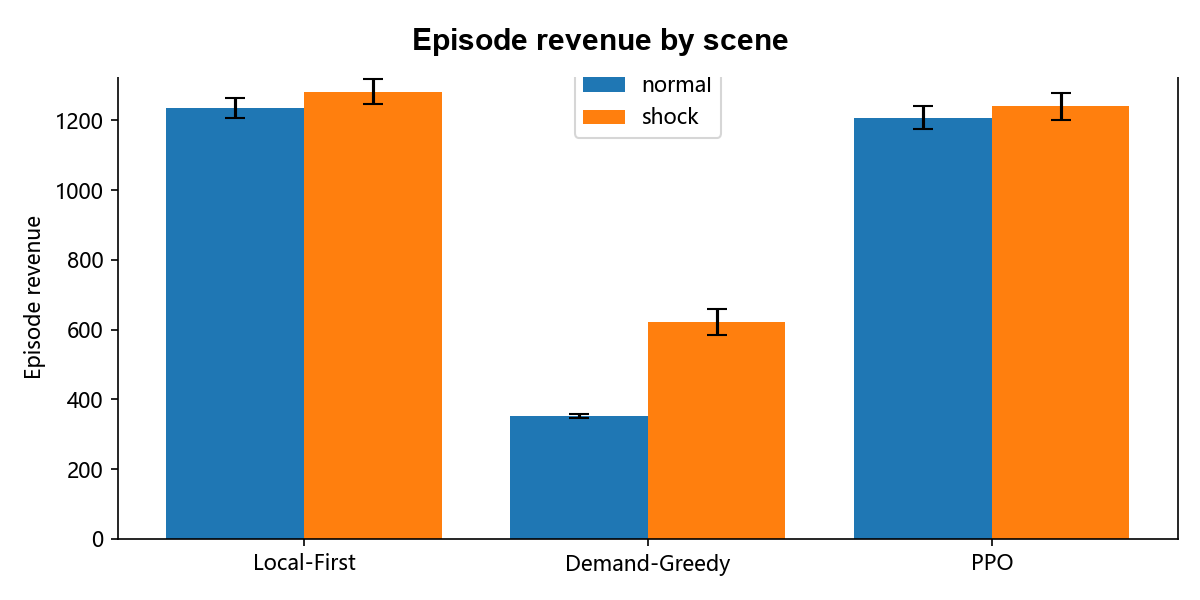

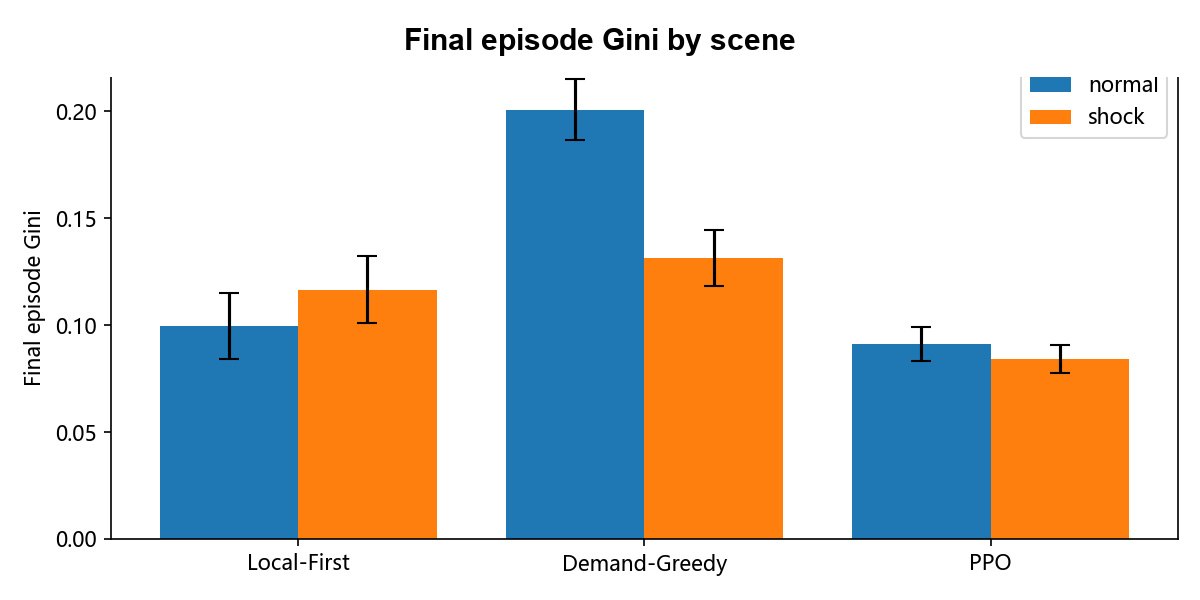

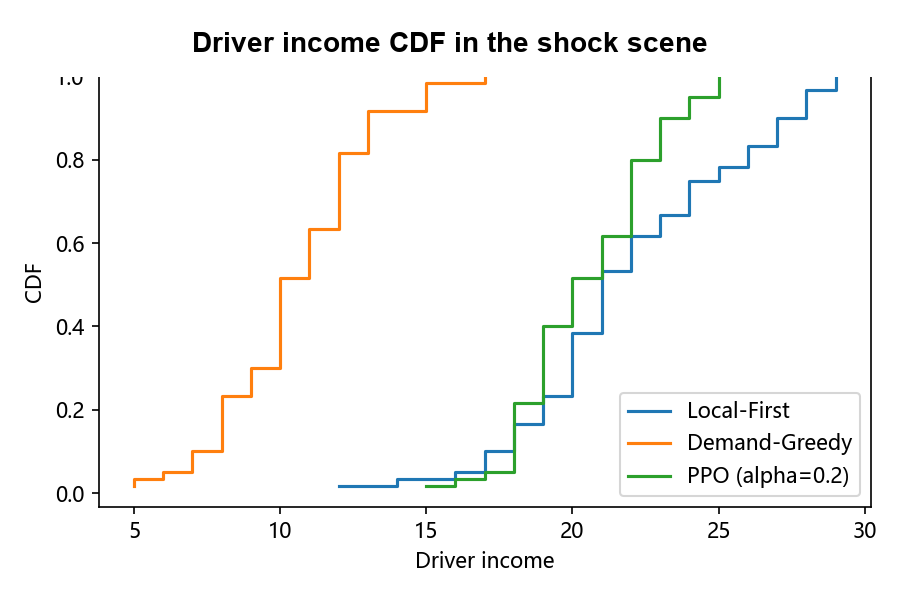

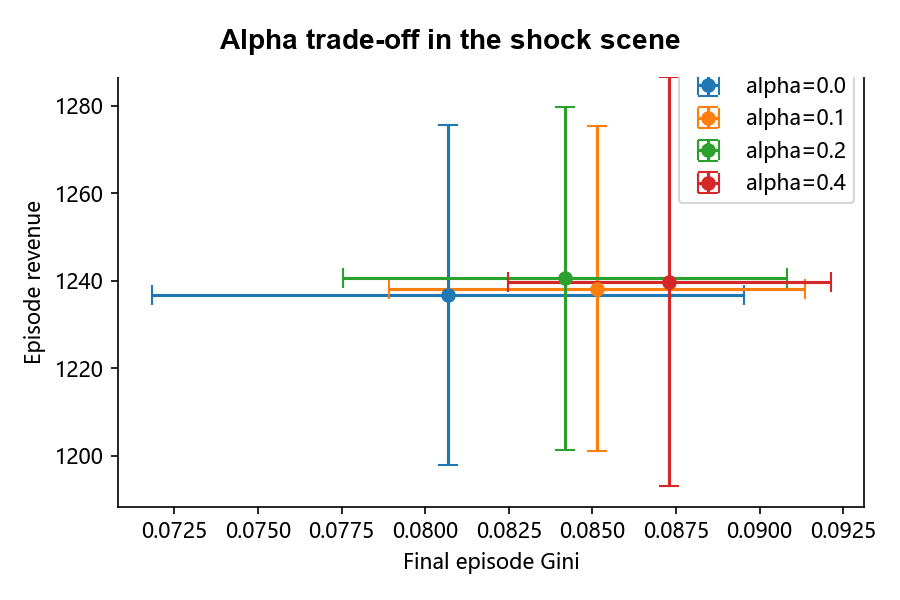

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

EXPORT_DIR = Path('figures')
EXPORT_DIR.mkdir(exist_ok=True)

# Load summary stats for error bars
stats_df = pd.read_csv('results/statistical_summary.csv')

# Figure 1: episode revenue by scene
algorithms = ['Local-First', 'Demand-Greedy', 'PPO']
normal_rev_mean = []
normal_rev_std = []
shock_rev_mean = []
shock_rev_std = []

for algo in algorithms:
    if algo == 'PPO':
        normal_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'normal') & (stats_df['alpha'] == 0.2)]
        shock_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock') & (stats_df['alpha'] == 0.2)]
    else:
        normal_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'normal')]
        shock_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'shock')]
    
    normal_rev_mean.append(normal_row['revenue_mean'].values[0])
    normal_rev_std.append(normal_row['revenue_std'].values[0])
    shock_rev_mean.append(shock_row['revenue_mean'].values[0])
    shock_rev_std.append(shock_row['revenue_std'].values[0])

positions = np.arange(len(algorithms))
plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, normal_rev_mean, width=0.4, yerr=normal_rev_std, capsize=5, label='normal')
plt.bar(positions + 0.2, shock_rev_mean, width=0.4, yerr=shock_rev_std, capsize=5, label='shock')
plt.xticks(positions, algorithms)
plt.ylabel('Episode revenue')
plt.title('Episode revenue by scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'episode_revenue_by_scene.png', dpi=150)
plt.show()
plt.close()

# Figure 2: final episode Gini by scene
normal_gini_mean = []
normal_gini_std = []
shock_gini_mean = []
shock_gini_std = []

for algo in algorithms:
    if algo == 'PPO':
        normal_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'normal') & (stats_df['alpha'] == 0.2)]
        shock_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock') & (stats_df['alpha'] == 0.2)]
    else:
        normal_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'normal')]
        shock_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'shock')]
    
    normal_gini_mean.append(normal_row['gini_mean'].values[0])
    normal_gini_std.append(normal_row['gini_std'].values[0])
    shock_gini_mean.append(shock_row['gini_mean'].values[0])
    shock_gini_std.append(shock_row['gini_std'].values[0])

plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, normal_gini_mean, width=0.4, yerr=normal_gini_std, capsize=5, label='normal')
plt.bar(positions + 0.2, shock_gini_mean, width=0.4, yerr=shock_gini_std, capsize=5, label='shock')
plt.xticks(positions, algorithms)
plt.ylabel('Final episode Gini')
plt.title('Final episode Gini by scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'final_gini_by_scene.png', dpi=150)
plt.show()
plt.close()

# Figure 3: driver income CDF in the shock scene
plt.figure(figsize=(6, 4))
for label, values in shock_income_samples.items():
    sorted_values = sorted(values)
    y_values = [(idx + 1) / len(sorted_values) for idx in range(len(sorted_values))]
    plt.step(sorted_values, y_values, where='post', label=label)
plt.xlabel('Driver income')
plt.ylabel('CDF')
plt.title('Driver income CDF in the shock scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'shock_income_cdf.png', dpi=150)
plt.show()
plt.close()

# Figure 4: alpha trade-off in the shock scene
ppo_shock_df = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock')].sort_values('alpha')
plt.figure(figsize=(6, 4))
for _, row in ppo_shock_df.iterrows():
    plt.errorbar(row['gini_mean'], row['revenue_mean'], 
                 xerr=row['gini_std'], yerr=row['revenue_std'],
                 fmt='o', capsize=5, label=f"alpha={row['alpha']}")
plt.xlabel('Final episode Gini')
plt.ylabel('Episode revenue')
plt.title('Alpha trade-off in the shock scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'alpha_tradeoff.png', dpi=150)
plt.show()
plt.close()


## Conclusion

From the numbers, the main takeaway is fairly clear. Demand shocks do create a real efficiency-fairness tension. `Demand-Greedy` performs badly in both scenes, while `Local-First` keeps revenue high but does not give the best fairness outcome. More importantly, `PPO(alpha=0.2)` produces a significantly lower `Gini` than `Local-First` in the `shock` scene (`p = 0.0028`), while the revenue gap is not statistically significant (`p = 0.118`). That is why the core conclusion of this project is simple: **with a better reward design, it is possible to reduce income inequality under demand shock without clear evidence of a major efficiency loss.**

This study also has clear limitations. The environment is region-level rather than order-level, so it leaves out realistic travel times, empty driving costs, matching constraints, and driver heterogeneity. The demand process is based on synthetic data and a `Poisson` generator, which makes the experiment easier to control but less realistic than actual ridesharing data. On top of that, the main results come from only `5` random seeds, so the statistical claims should be read as course-project evidence rather than a final statement about real platforms.

Future work should push the setup in a more realistic direction. The most obvious next step is to move to an order-level environment or real platform data and check whether the same conclusion still holds. It would also be useful to add richer fairness metrics, such as long-run income volatility, service fairness across zones, or minimum-income protection. Beyond that, the project could compare a wider set of RL and dispatch baselines, or run a more systematic sensitivity analysis by increasing the number of seeds and varying the shock location, duration, and reward weights.


## References

1. Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). Proximal policy optimization algorithms. arXiv preprint arXiv:1707.06347.

2. Xu, Z., Li, Z., Guan, Q., Zhang, D., Li, Q., Nan, J., ... & Ye, J. (2018). Large-scale order dispatch in on-demand ride-hailing platforms: A learning and planning approach. In Proceedings of the 24th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining (pp. 905-913).

3. Tang, K., Chen, S., & Liu, Z. (2019). A deep value-network based approach for multi-driver order dispatching. In Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining (pp. 1780-1790).

4. Qin, Z., Tang, X., Jiao, Y., Zhang, F., Xu, Z., He, H., & Ye, J. (2020). Reinforced imitation in heterogeneous action space. In Proceedings of the 26th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining (pp. 2604-2612).

5. Zheng, L., Chen, L., & Ye, J. (2021). Fairness-aware order dispatching via reinforcement learning. In Proceedings of the AAAI Conference on Artificial Intelligence (Vol. 35, No. 1, pp. 1-9).

6. Shi, C., Wan, R., Song, R., Lu, W., & Leng, L. (2022). Dynamic causal effects evaluation in A/B testing with a reinforcement learning framework. Journal of the American Statistical Association, 117(539), 1-15.

7. Wang, Z., Qin, Z., Tang, X., Ye, J., & Zhu, H. (2022). Optimizing long-term efficiency and fairness in ride-hailing via joint order dispatching and driver repositioning. In Proceedings of the 28th ACM SIGKDD Conference on Knowledge Discovery and Data Mining (pp. 1831-1841).

8. Li, M., Qin, Z., Jiao, Y., Yang, Y., Wang, J., Wang, C., ... & Ye, J. (2024). Fairness-aware dynamic ride-hailing matching based on reinforcement learning. Transportation Research Part C: Emerging Technologies, 158, 104442.


## Group Contribution Statement

This project was completed by a four-person group. Because the group worked on the same machine and shared the experimental workflow, the main parts of the project — environment design, algorithm implementation, experiment runs, statistical analysis, and report writing — were completed collaboratively.

**Group members**: [Names to be added]

**Main tasks**:
- Environment design and simulation implementation (`FairDispatchEnv`)
- Baseline policies (`Local-First`, `Demand-Greedy`)
- PPO training and tuning
- Multi-seed experiment design and execution (`5` seeds, `60` runs)
- Statistical analysis and significance testing (`t`-tests, Cohen's `d`)
- Visualization and figure generation
- Report writing and notebook integration

**Note**: Member names and final contribution percentages will be added before submission.
